In [1]:
import numpy as np 
import pandas as pd 
df = pd.read_csv(r"C:\Users\Vaibhav Desai\Desktop\Internshalla Data Analytics\Project 5\blackrock.csv")
pd.set_option('display.float_format', '{:,.2f}'.format)#changing output globally from scientific to financial format
df.head()

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,17-07-2023,"47,387.11","2,980.57",0.78,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,13-01-2023,"55,806.54","27,996.69",0.30,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,28-09-2023,"51,080.48","81,482.16",0.39,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,05-02-2023,"70,472.70","39,598.37",0.56,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,19-11-2023,"29,830.49","111,731.99",0.66,391,20


# **Task 1**:
##### Data Cleaning and Formatting 

In [3]:
#1.1
#Remove/treat any special characters or non-numeric entries from financial fields.
df[['TransactionAmount','AccountBalance']]=df[['TransactionAmount','AccountBalance']].fillna(0)#filling all null values as 0
df[['TransactionAmount','AccountBalance']].isnull().sum()#checking
df[['TransactionAmount','AccountBalance']] = df[['TransactionAmount','AccountBalance']].replace(r'[^\d.]','',regex=True)

In [4]:
#1.2
#Convert currency amounts into numerical format. 
print(df[['TransactionAmount','AccountBalance']].dtypes)#float is numerical format 

TransactionAmount    float64
AccountBalance       float64
dtype: object


In [5]:
#1.3
#Validate and format date columns.
df['TransactionDate']=pd.to_datetime(df['TransactionDate'], dayfirst=True)
print(df['TransactionDate'].isna().sum())#to check if any date was invalid or unparsble 
print(df['TransactionDate'].dtypes)#to show datatype changed from object to 

0
datetime64[ns]


In [6]:
#1.4
#Ensure account types and transaction categories are standardized. 
print(df['AccountType'].unique())
print(df['TransactionType'].unique())

['Credit' 'Current' 'Loan' 'Savings']
['Withdrawal' 'Payment' 'Deposit' 'Transfer']


# **Task 2** :
##### Descriptive Transactional Analysis 

In [8]:
#2.1
#Calculate monthly and yearly summaries of total credits, debits, and net transaction volume. 
#Debit = Withdrawal + Payment
#Credit = Deposit + Transfer
# Created a dataframe which spefically targets debit rows(rows with withdraw or payment TransactionType) and TransactionAmount and Date
debit_df= df.loc[df['TransactionType'].isin(['Withdrawal','Payment']),['AccountID','TransactionType','TransactionAmount','TransactionDate']]
# Created a dataframe which spefically targets credit rows(rows with Deposit or Transfer TransactionType) and TransactionAmount and Date
credit_df= df.loc[df['TransactionType'].isin(['Deposit','Transfer']),['AccountID','TransactionType','TransactionAmount','TransactionDate']]
#Calculate total debit per month by using groupby and .dt.to_period function
TDPM=debit_df.groupby(debit_df['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum()
#Calculate total debit per month by using groupby and .dt.to_period function
TCPM=credit_df.groupby(credit_df['TransactionDate'].dt.to_period('M'))['TransactionAmount'].sum()
#Calculate Net_transaction_Volume as count of Transactions per month 
#Net_Transaction_volme = TCPM + TDPM
Net_Transaction_Volume = df.groupby(df['TransactionDate'].dt.to_period('M'))['TransactionID'].count()
#Convert Each result into a seperate dataframe called df2 to store results for further tasks
df2 = pd.DataFrame({'Total Credit Per Month': TCPM, 'Total Debit Per Month': TDPM, 'Net Transaction Volume': Net_Transaction_Volume}).reset_index()
df2

,TransactionDate,Total Credit Per Month,Total Debit Per Month,Net Transaction Volume
0,2023-01,"902,271.34","1,329,907.25",48
1,2023-02,"1,492,377.29","1,674,317.61",54
2,2023-03,"921,980.04","1,397,222.53",39
3,2023-04,"826,125.08","1,273,478.39",40
4,2023-05,"1,955,004.48","1,320,213.14",67
5,2023-06,"1,133,683.93","531,862.96",32
6,2023-07,"862,390.41","1,047,056.87",35
7,2023-08,"504,453.84","1,511,240.03",40
8,2023-09,"1,379,303.55","1,565,613.94",52
9,2023-10,"2,194,982.46","1,973,336.69",73


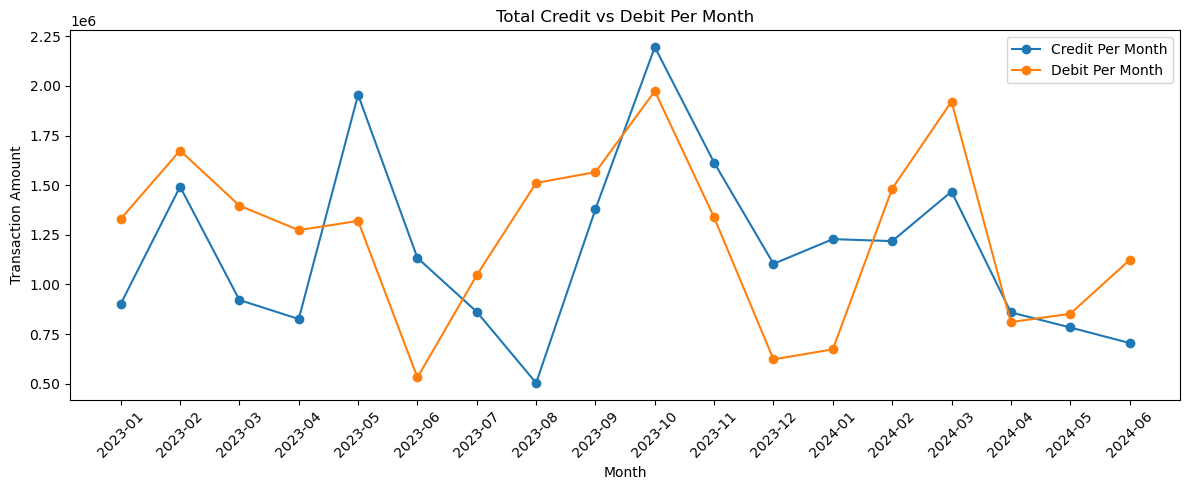

In [9]:
#2.2
#Plot trends in total credits vs. debits over time. 
import matplotlib.pyplot as plt 
#Converting index of Series to string for use in line plot
TCPM.index = TCPM.index.astype(str)
TDPM.index = TDPM.index.astype(str)
#using line plot to plot both the series TCPM and TDPM 
plt.figure(figsize=(12, 5))
plt.plot(TCPM, marker='o')
plt.plot(TDPM, marker='o')
plt.title('Total Credit vs Debit Per Month')
plt.xlabel('Month')
plt.ylabel('Transaction Amount')
plt.xticks(rotation=45)
plt.legend(['Credit Per Month','Debit Per Month'])
plt.tight_layout()
plt.show()

In [43]:
#2.3
#Identify top and bottom performing accounts based on net inflow
#Net Inflow = Total Credit per Account - Total Debit per Account
#Create a group by series, grouping Transactionamounts based on AccountIDs for debit 
TDPA=debit_df.groupby(debit_df['AccountID'])['TransactionAmount'].sum()
#Create a group by series, grouping Transactionamounts based on AccountIDs for credit 
TCPA=credit_df.groupby(credit_df['AccountID'])['TransactionAmount'].sum()
# Calculate Net_InFlow by using subtract function , to fill in missing values as 0 in either Credit or debit AccountID rows
# Meaning when TCPA has one account ID with TDPA as NaN(As in there is no debit for this accountid) it will fill it as 0
# this is required because it maintains AccountID has Index for Net_InFlow Series, while just simple minus was insufficient for this task
Net_InFlow = TCPA.subtract(TDPA, fill_value=0)
#Create Dataframe for further use of Net_InFLow, here AccountID is the Index, we reset the index so AccountID becomes another column in the dataframe
net_inFlow_df = pd.DataFrame({'Total Credit Per Account': TCPA,'Total Debit Per Account': TDPA,'Net Inflow': Net_InFlow}).fillna(0).reset_index().sort_values('Net Inflow',ascending=False)
#Top 5 largest by net inflow
t5=net_inFlow_df.nlargest(5,'Net Inflow').reset_index(drop=True)
#starting the index at 1 instead of 0
t5.index = t5.index+1
#Top 5 smallest by net inflow
b5=net_inFlow_df.nsmallest(5,'Net Inflow').reset_index(drop=True)
#starting the index at 1 instead of 0
b5.index = b5.index+1
print(f"The top 5 accounts based on net inflow are:\n {t5}\n\n")
print(f"The bottom 5 accounts based on net inflow are:\n {b5}")

The top 5 accounts based on net inflow are:
   AccountID  Total Credit Per Account  Total Debit Per Account  Net Inflow
1  ACC88286                284,230.60                     0.00  284,230.60
2  ACC21719                281,795.52                 7,066.33  274,729.19
3  ACC55729                232,814.43                     0.00  232,814.43
4  ACC34821                222,247.32                     0.00  222,247.32
5  ACC76597                334,856.40               120,669.18  214,187.23


The bottom 5 accounts based on net inflow are:
   AccountID  Total Credit Per Account  Total Debit Per Account  Net Inflow
1  ACC35419                 32,955.23               398,856.44 -365,901.20
2  ACC71938                      0.00               353,666.21 -353,666.21
3  ACC45101                 80,552.28               430,644.58 -350,092.29
4  ACC24070                      0.00               338,136.69 -338,136.69
5  ACC97411                 50,949.04               365,710.86 -314,761.83


In [11]:
#2.4
# Identify and flag accounts as dormant or inactive if there is a gap of two months or more 
# between consecutive transactions.
#Created a copy so the dataframe is independent from the original DataFrame, making it changable and sortable whitout changing the original Dataframe 
df3 = df[['AccountID','TransactionID','TransactionDate','AccountType']].copy()
#Sorted the values based on accountID and TransactionDate, so each transaction in each accountID is sorted by date 
df3 = df3.sort_values(['AccountID','TransactionDate']).reset_index(drop=True)
#Accessing Previous Date using Shift(1) function. 
df3['PrevTransactionDate'] = df3.groupby('AccountID')['TransactionDate'].shift(1)
#Calculating Difference in months between consecutive transactions 
df3['MonthDiff'] = ((df3['TransactionDate'].dt.year  - df3['PrevTransactionDate'].dt.year) * 12 +
                    (df3['TransactionDate'].dt.month - df3['PrevTransactionDate'].dt.month))
#Calculates Max Month Diff between trnasactions 
max_month_diff = df3.groupby('AccountID')['MonthDiff'].max()
#Transactions per Account 
txn_count = df3.groupby('AccountID')['TransactionID'].count()
#created a summary dataframe to cleanly display Which accounts are Dormant and which are active 
summary_df = pd.DataFrame({
    'Max Month Gap':        max_month_diff,
    'Transaction Count':    txn_count,
}).reset_index().query('`Transaction Count` >=2')
summary_df['AccountStatus'] = np.where(summary_df['Max Month Gap']>=2,"Dormant","Active")
display(summary_df)
# active_acc = summary_df.loc[summary_df['AccountStatus']=='Active']['AccountID'].count()
# acc_dor = df.loc[df['AccountID'].isin(summary_df.loc[summary_df['AccountStatus']=='Dormant','AccountID'])]
# acc_type_dor = acc_dor.groupby('AccountID')['AccountType'].first().value_counts()
# print(acc_type_dor)
# print(active_acc)

,AccountID,Max Month Gap,Transaction Count,AccountStatus
0,ACC10117,3.00,6,Dormant
1,ACC10996,4.00,4,Dormant
2,ACC11062,6.00,6,Dormant
3,ACC11188,6.00,9,Dormant
4,ACC11285,7.00,5,Dormant
...,...,...,...,...
186,ACC96868,10.00,2,Dormant
187,ACC97225,6.00,3,Dormant
188,ACC97411,7.00,8,Dormant
190,ACC99409,5.00,3,Dormant


# **Task 3**: 
##### Customer Profile Building


In [13]:
# 3.1 
# Group accounts by activity levels: High, Medium, Low based on transaction frequency on 
# your analysis and rubrics. Do not forget to mention the rubric in the headings. 

txn_count = df3.groupby('AccountID')['TransactionID'].count() #used count function from previous task
p25 = txn_count.quantile(0.25) # used percentile to quanitfy low transactions 
p75 = txn_count.quantile(0.75) #used percentiles to quanitfy high and medium trnasactions 
summary_df['Activity Levels']=np.where(summary_df['Transaction Count'] > p75, 'High',
                                                                                     np.where(summary_df['Transaction Count'] > p25, 'Medium', 'Low'))
print("Rubric used in task: (High>=75%ile),(75%ile>Medium>=25%ile),(25%ile>Low)")
print(f"75%ile is : {p75}, 25%ile is: {p25}")
display(summary_df)
print(summary_df['Activity Levels'].value_counts().sort_values())

Rubric used in task: (High>=75%ile),(75%ile>Medium>=25%ile),(25%ile>Low)
75%ile is : 5.0, 25%ile is: 3.0


,AccountID,Max Month Gap,Transaction Count,AccountStatus,Activity Levels
0,ACC10117,3.00,6,Dormant,High
1,ACC10996,4.00,4,Dormant,Medium
2,ACC11062,6.00,6,Dormant,High
3,ACC11188,6.00,9,Dormant,High
4,ACC11285,7.00,5,Dormant,Medium
...,...,...,...,...,...
186,ACC96868,10.00,2,Dormant,Low
187,ACC97225,6.00,3,Dormant,Low
188,ACC97411,7.00,8,Dormant,High
190,ACC99409,5.00,3,Dormant,Low


Activity Levels
High      45
Medium    68
Low       71
Name: count, dtype: int64


In [166]:
#3.2
#Segment customers by average balance and transaction volume. 
df4 = df[['AccountID','AccountBalance','TransactionAmount']].copy()
Cus_avg = df4.groupby('AccountID')['AccountBalance'].mean()
txn_count_cus = df4.groupby('AccountID')['TransactionAmount'].sum()
Cus_segment_df = pd.DataFrame({ 'Average Balance': Cus_avg , 
                    'Total Transaction Volume': txn_count_cus    
}).reset_index()
# Calculate percentiles
bal_p75 = Cus_segment_df['Average Balance'].quantile(0.75)
bal_p25 = Cus_segment_df['Average Balance'].quantile(0.25)
vol_p75 = Cus_segment_df['Total Transaction Volume'].quantile(0.75)
vol_p25 = Cus_segment_df['Total Transaction Volume'].quantile(0.25)

# Segment customers
Cus_segment_df['Customer Segment'] = np.where(
    (Cus_segment_df['Average Balance'] >= bal_p75) | (Cus_segment_df['Total Transaction Volume'] >= vol_p75),
    'Premium',
np.where(
    (Cus_segment_df['Average Balance'] >= bal_p25) & (Cus_segment_df['Total Transaction Volume'] >= vol_p25),
    'Moderate',
    'Low Value'
))
display(Cus_segment_df)
print(Cus_segment_df['Customer Segment'].value_counts().sort_values())


,AccountID,Average Balance,Total Transaction Volume,Customer Segment
0,ACC10117,"81,106.21","246,887.29",Moderate
1,ACC10996,"101,733.90","358,817.02",Premium
2,ACC11062,"57,108.76","328,776.97",Premium
3,ACC11188,"80,235.15","386,419.02",Premium
4,ACC11285,"71,205.65","284,440.53",Moderate
...,...,...,...,...
187,ACC97225,"53,496.78","106,202.50",Low Value
188,ACC97411,"89,407.83","416,659.90",Premium
189,ACC99117,"106,391.25","92,159.60",Premium
190,ACC99409,"55,933.33","155,509.75",Low Value


Customer Segment
Moderate     49
Low Value    56
Premium      87
Name: count, dtype: int64


In [73]:
# 3.3 Create profiles for: 
# ○ High-net inflow accounts 
# ○ High-frequency low-balance accounts 
# ○ Accounts with negative or near-zero balances 
def profile (choice):
    if choice == 1:
        # Accounts where Net Inflow is above 75th percentile
        p75_inflow = net_inFlow_df['Net Inflow'].quantile(0.75)
        
        high_inflow_ids = net_inFlow_df[net_inFlow_df['Net Inflow'] >= p75_inflow]['AccountID']
        
        high_inflow = summary_df[['AccountID','Transaction Count']].merge(
            net_inFlow_df[['AccountID', 'Net Inflow']], on='AccountID', how='left'
        ).merge(
            df[['AccountID', 'AccountBalance','AccountType','Product','Firm','Manager','RiskScore','CreditRating','TenureMonths']],
            on='AccountID', how='left'
        )
        
        high_inflow = high_inflow[high_inflow['AccountID'].isin(high_inflow_ids)]
        
        profile = high_inflow.groupby('AccountID').agg(
            Transaction_Count=('Transaction Count', 'first'),
            Net_Inflow=('Net Inflow', 'first'),
            AccountBalance=('AccountBalance', 'first'),
            AccountType=('AccountType', 'first'),
            Product=('Product', 'first'),
            Firm=('Firm', 'first'),
            Manager=('Manager', 'first'),
            RiskScore=('RiskScore', 'first'),
            CreditRating=('CreditRating', 'first'),
            TenureMonths=('TenureMonths', 'first')
        ).reset_index()
        
        print("Profile 1: High Net Inflow Accounts")

    elif choice == 2:
        #High-frequency low-balance accounts 
        
        high_frequency_low_balance = summary_df[['AccountID','Transaction Count']].merge(
            df[['AccountID', 'AccountBalance','AccountType','Product','Firm','Manager','RiskScore','CreditRating','TenureMonths']],
            on='AccountID',
            how='left'
        )
        p75 = high_frequency_low_balance['Transaction Count'].quantile(0.75)
        b25 = high_frequency_low_balance['AccountBalance'].quantile(0.25)
        high_frequency_low_balance = high_frequency_low_balance.loc[
            (high_frequency_low_balance['Transaction Count'] >= p75) &
            (high_frequency_low_balance['AccountBalance']   <= b25)
        ].reset_index(drop=True)
        
        profile = high_frequency_low_balance.groupby('AccountID')[['Transaction Count','AccountBalance','AccountType',
                                                     'Product','Firm','Manager','RiskScore','CreditRating','TenureMonths']].first().reset_index()
        print("Profile 2: High-Frequency Low-Balance Accounts")
        
    elif choice == 3: 
        # Accounts with negative or near-zero balances
        profile = df.sort_values('AccountBalance', ascending=True).query('AccountBalance <= 10').reset_index(drop=True)
        print("Profile 3: Negative or Near-Zero Balance Accounts")
    else:
        print("Invalid choice. Please enter 1, 2, or 3.")
        return

    display(profile)
# Block to select which customer profile is wanted 
print("1 - High Net Inflow Accounts")
print("2 - High-Frequency Low-Balance Accounts")
print("3 - Negative or Near-Zero Balance Accounts")

choice = input("Enter your choice: \n")
print("\n")
profile(int(choice))

1 - High Net Inflow Accounts
2 - High-Frequency Low-Balance Accounts
3 - Negative or Near-Zero Balance Accounts


Enter your choice: 
 3




Profile 3: Negative or Near-Zero Balance Accounts


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,65,CUST6565,ACC39529,Savings,Withdrawal,Credit Card,Firm B,East,Manager 2,2023-02-05,"39,997.81","-35,891.00",0.34,675,174
1,170,CUST3315,ACC34821,Savings,Transfer,Credit Card,Firm E,West,Manager 3,2023-02-04,"47,774.00","-32,532.52",0.69,684,91
2,68,CUST9731,ACC46953,Loan,Payment,Credit Card,Firm A,West,Manager 3,2023-10-24,"44,911.00","-26,968.23",0.11,512,227
3,54,CUST2578,ACC78589,Credit,Withdrawal,Savings Account,Firm A,South,Manager 4,2023-09-06,"77,094.30","-25,971.51",0.41,519,227
4,102,CUST1962,ACC45521,Savings,Withdrawal,Home Loan,Firm C,South,Manager 4,2023-10-22,"66,964.49","-18,963.80",1.08,808,118
5,129,CUST3153,ACC64022,Loan,Withdrawal,Credit Card,Firm D,Central,Manager 4,2024-01-29,"62,066.90","-11,356.98",0.40,814,110
6,20,CUST9843,ACC88516,Savings,Payment,Home Loan,Firm C,North,Manager 3,2023-01-13,"39,126.36","-9,208.20",0.91,469,182
7,37,CUST6210,ACC11062,Savings,Transfer,Mutual Fund,Firm C,North,Manager 2,2023-02-14,"66,872.65","-9,084.22",0.35,737,190
8,173,CUST6210,ACC74631,Savings,Deposit,Home Loan,Firm C,South,Manager 4,2023-01-08,"72,738.26","-8,820.48",0.71,743,23
9,198,CUST5610,ACC15671,Savings,Withdrawal,Mutual Fund,Firm D,East,Manager 4,2024-02-05,"54,668.94","-8,225.60",0.63,493,172


# **Task 4**: 
#####  Financial Risk Identification


In [75]:
# 4.1
# Track accounts with frequent large withdrawals or overdrafts.

#frequent and Large Withdrawals 
withdrawals_df =df.loc[df['TransactionType'].isin(['Withdrawal','Payment']),
                    ['AccountID','TransactionType','TransactionAmount','TransactionDate','AccountBalance','TransactionID']]

# First, get one row per account
txn_count_df = summary_df[['AccountID', 'Transaction Count']].merge(
    df.groupby('AccountID', as_index=False).agg(
        TotalTransactionAmount=('TransactionAmount', 'sum'),
        AccountBalance=('AccountBalance', 'last')
    ),
    on='AccountID', how='left'
).sort_values('Transaction Count', ascending=False)

# Step 2: Define statistical thresholds
# .quantile(0.75) returns the value at the 75th percentile of TransactionAmount
# any transaction above this value is considered statistically large
amount_threshold = withdrawals_df['TransactionAmount'].quantile(0.75)

# Step 3: Average large transaction amount per account
# we first filter withdrawals_df to only include large transactions
# then group by AccountID and take the mean TransactionAmount
# this tells us how large the typical large transaction is for each account
avg_large_amount = withdrawals_df[withdrawals_df['TransactionAmount'] >= amount_threshold].groupby(
    'AccountID')['TransactionAmount'].mean().reset_index(name='Avg Large Amount')

# Step 4: Count of large transactions per account
# .size() counts the number of rows in each group, i.e. how many large transactions each account made
# this tells us how frequently each account makes large transactions
large_txn_count = withdrawals_df[withdrawals_df['TransactionAmount'] >= amount_threshold].groupby(
    'AccountID').size().reset_index(name='Large Txn Count')

# Step 5: Merge and fill
# accounts with no large transactions will have NaN after the left merge
# .fillna(0) replaces those NaN values with 0 so they score lowest in the risk scoring
txn_count_df = txn_count_df.merge(avg_large_amount, on='AccountID', how='left')
txn_count_df = txn_count_df.merge(large_txn_count, on='AccountID', how='left')
txn_count_df[['Avg Large Amount', 'Large Txn Count']] = txn_count_df[['Avg Large Amount', 'Large Txn Count']].fillna(0)

# Step 6: Compute scores internally
# Min-Max normalisation formula: (value - min) / (max - min)
# this ensures both metrics contribute equally to the final score
# without normalisation, a metric with larger values (e.g. amount) would dominate the score
# these are stored as temporary variables and not added to the dataframe
amount_score = (txn_count_df['Avg Large Amount'] - txn_count_df['Avg Large Amount'].min()) / \
               (txn_count_df['Avg Large Amount'].max() - txn_count_df['Avg Large Amount'].min())

frequency_score = (txn_count_df['Large Txn Count'] - txn_count_df['Large Txn Count'].min()) / \
                  (txn_count_df['Large Txn Count'].max() - txn_count_df['Large Txn Count'].min())
# combined risk score is the equal weighted average of both normalised scores
# a score closer to 1 means the account is both a frequent and large transactor
risk_score = (amount_score + frequency_score) / 2

# Step 7: Flag overdraft accounts
# we group by AccountID and take the minimum AccountBalance across all their transactions
# if the minimum balance is below 0 at any point, the account has gone into overdraft
overdraft_accounts = withdrawals_df.groupby('AccountID')['AccountBalance'].min().reset_index(name='Min Balance')
overdraft_accounts['Is Overdraft'] = overdraft_accounts['Min Balance'] < 0

# Step 8: Merge overdraft flag
# accounts not present in withdrawals_df will have NaN for Is Overdraft
# .fillna(False) ensures these accounts are not incorrectly flagged as overdraft
txn_count_df = txn_count_df.merge(overdraft_accounts[['AccountID', 'Is Overdraft']], 
                                   on='AccountID', how='left')
txn_count_df['Is Overdraft'] = txn_count_df['Is Overdraft'].fillna(False)

# Step 9: Final high risk flag
# an account is High Risk if EITHER condition is true:
# 1. their risk score falls in the top 25% (75th percentile) of all accounts
# 2. their account balance has gone into overdraft at any point
# the | operator is a bitwise OR that combines both boolean conditions
txn_count_df['High Risk'] = (
    (amount_score >= amount_score.quantile(0.75)) &
    (txn_count_df['Large Txn Count'] >= 3)
) | (txn_count_df['Is Overdraft'] == True)

# Step 10: Drop intermediate columns and sort
# we drop Avg Large Amount and Large Txn Count as they were only needed to compute the risk score
# the final dataframe shows only the columns relevant for business review
txn_count_df = txn_count_df.drop(columns=['Avg Large Amount', 'Large Txn Count']) \
                            .sort_values('Transaction Count', ascending=False)
#Step 11: Only Shows Flagged Accounts 
flagged_df = txn_count_df[txn_count_df['High Risk'] == True].reset_index(drop=True)
display(flagged_df)

C:\Users\Vaibhav Desai\AppData\Local\Temp\ipykernel_524\438776438.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  txn_count_df['Is Overdraft'] = txn_count_df['Is Overdraft'].fillna(False)


,AccountID,Transaction Count,TotalTransactionAmount,AccountBalance,Is Overdraft,High Risk
0,ACC45521,7,"268,616.53","26,908.76",True,True
1,ACC45101,7,"511,196.86","110,349.68",True,True
2,ACC35419,6,"431,811.67","86,819.57",False,True
3,ACC24070,5,"338,136.69","82,995.63",False,True
4,ACC64022,5,"219,205.79","-11,356.98",True,True
5,ACC94907,5,"292,090.72","-7,738.89",True,True
6,ACC10996,4,"358,817.02","97,859.88",False,True
7,ACC71938,4,"353,666.21","61,517.35",False,True
8,ACC88516,4,"206,677.53","81,086.45",True,True
9,ACC15671,3,"134,497.96","39,629.93",True,True


,AccountID,Standard Deviation per Account,Coeffiecient of Variation per Account
0,ACC10117,"30,732.94",37.89
1,ACC10996,"12,477.43",12.26
2,ACC11062,"40,017.80",70.07
3,ACC11188,"25,420.45",31.68
4,ACC11285,"35,772.56",50.24
...,...,...,...
186,ACC96868,"66,366.90",73.64
187,ACC97225,"51,171.43",95.65
188,ACC97411,"30,357.59",33.95
190,ACC99409,"46,489.35",83.12


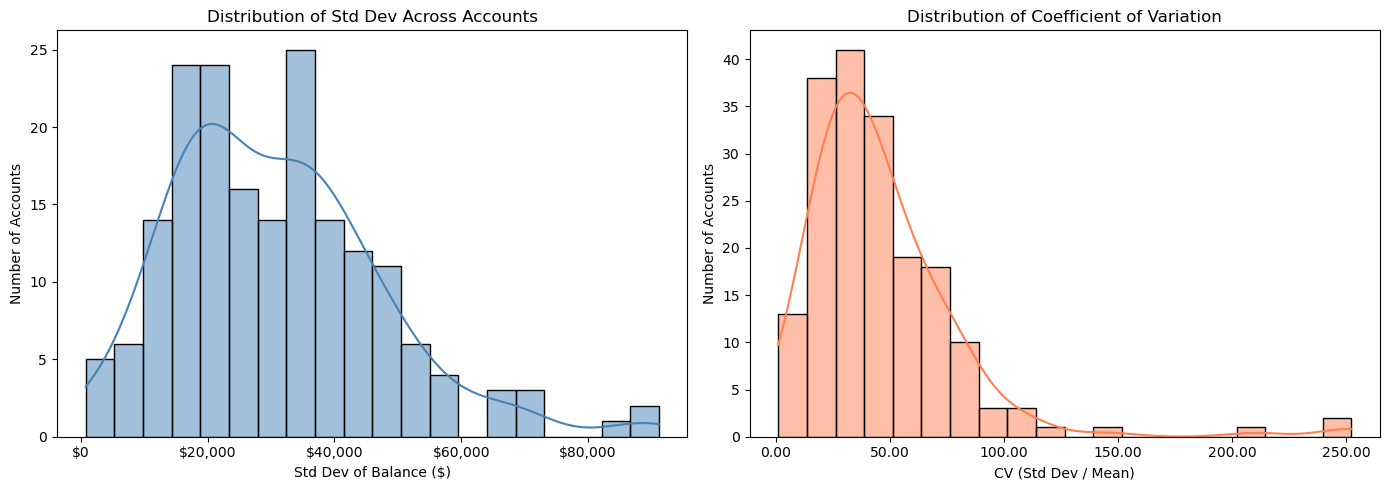

In [97]:
#4.2 Calculate balance volatility using standard deviation or coefficient of variation. 
import seaborn as sns 
Account_std = df.groupby(df['AccountID'])['AccountBalance'].std()# calculating standard deviation 
Account_cov = df.groupby(df['AccountID'])['AccountBalance'].apply(lambda x : (x.std()/x.mean())*100)#calculating coefficient of variation. 
Account_std_df=pd.DataFrame({'Standard Deviation per Account' : Account_std, 'Coeffiecient of Variation per Account': Account_cov}).reset_index()
Account_std_clean = Account_std_df.dropna(subset=['Standard Deviation per Account'])#dropping accountIDs with only 1 transaction

Account_std_clean.index = Account_std_clean.index.astype(str)# converting index to string for using in plotting
display(Account_std_clean)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Std Dev histogram 
sns.histplot(
    data=Account_std_clean,
    x='Standard Deviation per Account',
    bins=20,
    kde=True,
    color='steelblue',
    ax=axes[0]
)
axes[0].set_title('Distribution of Std Dev Across Accounts')
axes[0].set_xlabel('Std Dev of Balance ($)')
axes[0].set_ylabel('Number of Accounts')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')#formatting x-axis to show numbers 
)

# Chart 2: CV histogram 
sns.histplot(
    data=Account_std_clean,
    x='Coeffiecient of Variation per Account',                   
    bins=20,
    kde=True,
    color='coral',
    ax=axes[1]
)
axes[1].set_title('Distribution of Coefficient of Variation')
axes[1].set_xlabel('CV (Std Dev / Mean)')
axes[1].set_ylabel('Number of Accounts')
axes[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.2f}')
)

plt.tight_layout()
plt.show() 

In [99]:
#4.3 Use IQR or z-score methods to detect anomalies. 
from scipy.stats import zscore
Account_zscore = zscore(df['AccountBalance']) 
suspicious_transactions = df[Account_zscore >= 2.6].reset_index(drop=True)# taking zscore criteria as 2.6
display(suspicious_transactions)


,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,88,CUST5705,ACC71426,Current,Deposit,Credit Card,Firm B,North,Manager 4,2023-05-24,"53,019.90","162,291.35",0.34,490,133
1,101,CUST4346,ACC65545,Current,Payment,Mutual Fund,Firm D,North,Manager 2,2023-09-10,"68,809.85","171,767.66",0.48,745,229
2,148,CUST7345,ACC88252,Credit,Deposit,Home Loan,Firm B,West,Manager 2,2024-03-02,"73,301.42","164,049.71",0.55,631,7
3,15,CUST4769,ACC28295,Current,Withdrawal,Home Loan,Firm B,East,Manager 4,2023-08-18,"62,636.52","163,654.25",-0.16,659,111
4,161,CUST4684,ACC66086,Credit,Transfer,Savings Account,Firm C,South,Manager 1,2024-04-06,-26.11,"166,720.44",0.37,626,92


In [111]:
#4.4 Highlight customers with irregular or suspicious transaction behavior. 
dfr=df.sort_values(['RiskScore'],ascending = False)
#to find irregularities i have taken range from less than equal zero  to 1 and above
df_irregular = dfr.loc[
    (dfr['RiskScore'] >= 1)| (dfr['RiskScore']<= 0)].reset_index(drop=True)
df_irregular[['CustomerID','RiskScore']]

,CustomerID,RiskScore
0,CUST2716,1.20
1,CUST7255,1.16
2,CUST5664,1.13
3,CUST7002,1.13
4,CUST1962,1.08
5,CUST1042,1.08
6,CUST5500,1.07
7,CUST4126,1.04
8,CUST6937,1.01
9,CUST4769,1.01


# **Task 5**: 
#####  Exploratory Data Ananlysis 

## EDA - Exploratory Data Analysis 
### It inlcudes data cleaning, data exploration and data preprocessing.
1. It helps understand the structure of the data
2. It helps understand basic to advanced features of the data
3. It helps understand the data statistically as well as analytically
4. It helps make business decisions about the data
5. Visualisation is an integral part of EDA since it helps in data exploration

## Three Types of EDA
1. Univariate - Exploring one column at a time 
2. Bivariate - Exploring two columns at a time
3. Multivariate - Exploring more than two columns at a time

In [113]:
df.head()# to begin EDA, we see roughly what the data looks like 

,TransactionID,CustomerID,AccountID,AccountType,TransactionType,Product,Firm,Region,Manager,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
0,109,CUST1913,ACC64393,Credit,Withdrawal,Home Loan,Firm A,West,Manager 1,2023-07-17,"47,387.11","2,980.57",0.78,784,170
1,19,CUST1569,ACC66190,Current,Payment,Personal Loan,Firm C,South,Manager 4,2023-01-13,"55,806.54","27,996.69",0.30,336,197
2,14,CUST5558,ACC71426,Current,Withdrawal,Mutual Fund,Firm C,North,Manager 2,2023-09-28,"51,080.48","81,482.16",0.39,712,95
3,107,CUST4241,ACC49422,Loan,Deposit,Credit Card,Firm D,Central,Manager 1,2023-02-05,"70,472.70","39,598.37",0.56,414,168
4,7,CUST2578,ACC88252,Loan,Deposit,Savings Account,Firm B,East,Manager 4,2023-11-19,"29,830.49","111,731.99",0.66,391,20


In [115]:
df.shape # see the total number of rows and columns 

(800, 15)

In [117]:
df.isnull().sum()# check to see if Data is properly rid of null values 

TransactionID        0
CustomerID           0
AccountID            0
AccountType          0
TransactionType      0
Product              0
Firm                 0
Region               0
Manager              0
TransactionDate      0
TransactionAmount    0
AccountBalance       0
RiskScore            0
CreditRating         0
TenureMonths         0
dtype: int64

In [119]:
df.describe() #Responsible for providing summary statistics about the numerical columns

,TransactionID,TransactionDate,TransactionAmount,AccountBalance,RiskScore,CreditRating,TenureMonths
count,800.00,800,800.00,800.00,800.00,800.00,800.00
mean,100.70,2023-09-18 23:40:12,"54,501.87","72,947.11",0.47,580.01,125.25
min,1.00,2023-01-06 00:00:00,"-27,916.91","-35,891.00",-0.29,306.00,6.00
25%,50.75,2023-05-11 00:00:00,"34,600.68","51,133.06",0.31,451.75,68.00
50%,98.50,2023-09-29 00:00:00,"55,524.08","73,006.75",0.46,575.00,127.00
75%,154.00,2024-02-04 00:00:00,"73,485.55","94,553.23",0.63,712.25,183.25
max,199.00,2024-06-22 00:00:00,"165,004.54","171,767.66",1.20,849.00,239.00
std,58.59,NaN,"29,676.38","34,206.07",0.23,154.08,67.30


In [121]:
df['Product'].value_counts()

Product
Home Loan          190
Credit Card        188
Savings Account    144
Mutual Fund        142
Personal Loan      136
Name: count, dtype: int64

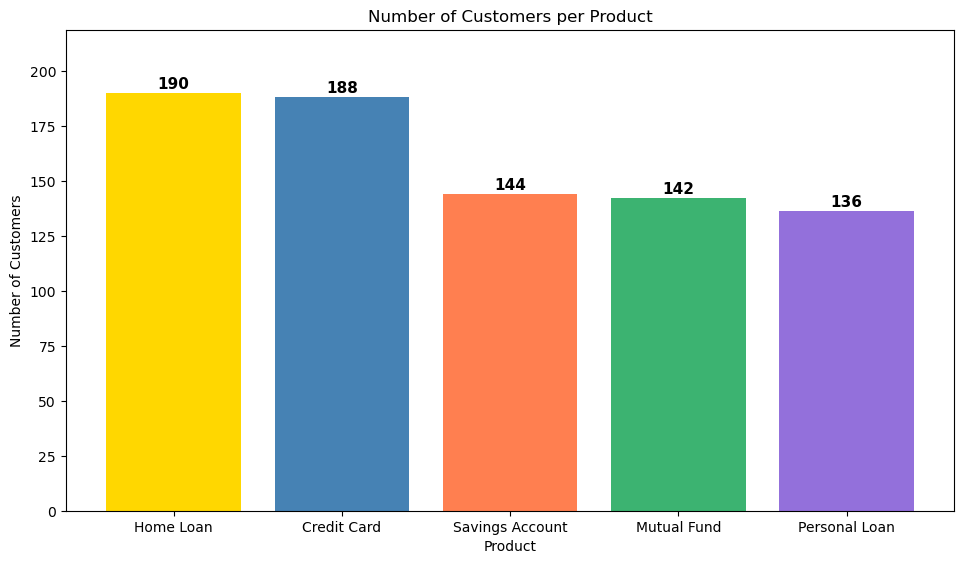

In [123]:
# Number of customers per Product
cus_product = df.groupby('Product')['CustomerID'].count()
cus_product_df = cus_product.reset_index()
cus_product_df.columns = ['Product','Number of Customers']
cus_product_df = cus_product_df.sort_values('Number of Customers', ascending=False)# sorting according to descending number of customers per product

color_map = {
    'Home Loan'      : 'gold',
    'Credit Card'    : 'steelblue',
    'Savings Account': 'coral',
    'Mutual Fund'    : 'mediumseagreen',
    'Personal Loan'  : 'mediumpurple'
} # dictionary for colors based on product type 

colors = [color_map[p] for p in cus_product_df['Product']]# list comprehension to extract color value per product type 
fig, ax1 = plt.subplots(figsize = (10,6))
ax1.bar(cus_product_df['Product'],cus_product_df['Number of Customers'], color=colors)
ax1.set_title('Number of Customers per Product')
ax1.set_xlabel('Product')
ax1.set_ylabel('Number of Customers')
ax1.set_ylim(0, cus_product_df['Number of Customers'].max() * 1.15)#increasing y limit  

for i, v in enumerate(cus_product_df['Number of Customers']):
    ax1.text(i, v + 2, str(v), ha='center', fontsize=11, fontweight='bold')# adding value above each bar, for better readibility

plt.tight_layout(pad = 2)
plt.show()

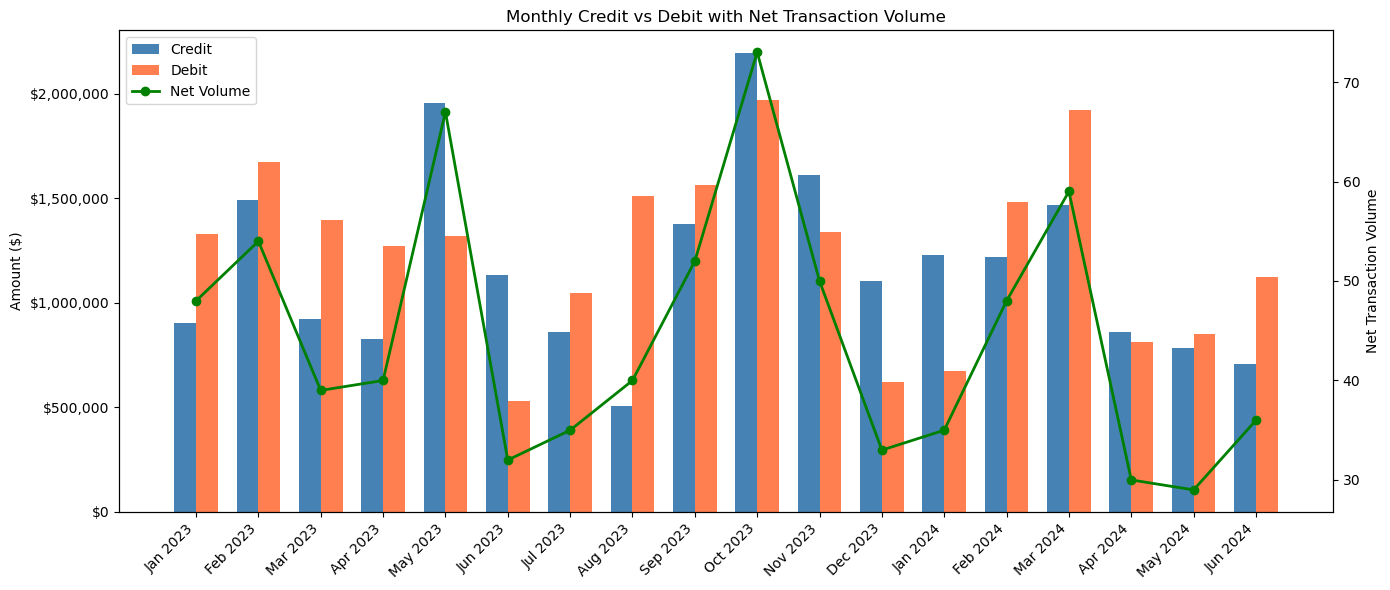

In [149]:
#monthly and yearly summaries of Credit vs debit and net trnasaction volume 
import matplotlib.ticker as mticker
df2.index =  df2.index.to_timestamp()
df2 = df2.sort_index()#dataframe containing total credits vs debits and net volume arranged month wise 
months = df2.index.strftime('%b %Y')
x = np.arange(len(months))
width = 0.35

fig, ax1 = plt.subplots(figsize=(14, 6))

# Grouped bars: Credit and Debit 
ax1.bar(x - width/2, df2['Total Credit Per Month'], width, label='Credit', color='steelblue')
ax1.bar(x + width/2, df2['Total Debit Per Month'],  width, label='Debit',  color='coral')
ax1.set_ylabel('Amount ($)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_xticks(x)
ax1.set_xticklabels(months, rotation=45, ha='right')

# Line overlay: Net Volume on secondary axis 
ax2 = ax1.twinx()# creating a secondary axis so as to maintain consistency with data for the net transaction line graph 
ax2.plot(x, df2['Net Transaction Volume'], color='green', marker='o', linewidth=2, label='Net Volume')
ax2.set_ylabel('Net Transaction Volume')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Monthly Credit vs Debit with Net Transaction Volume')
plt.tight_layout()
plt.show()

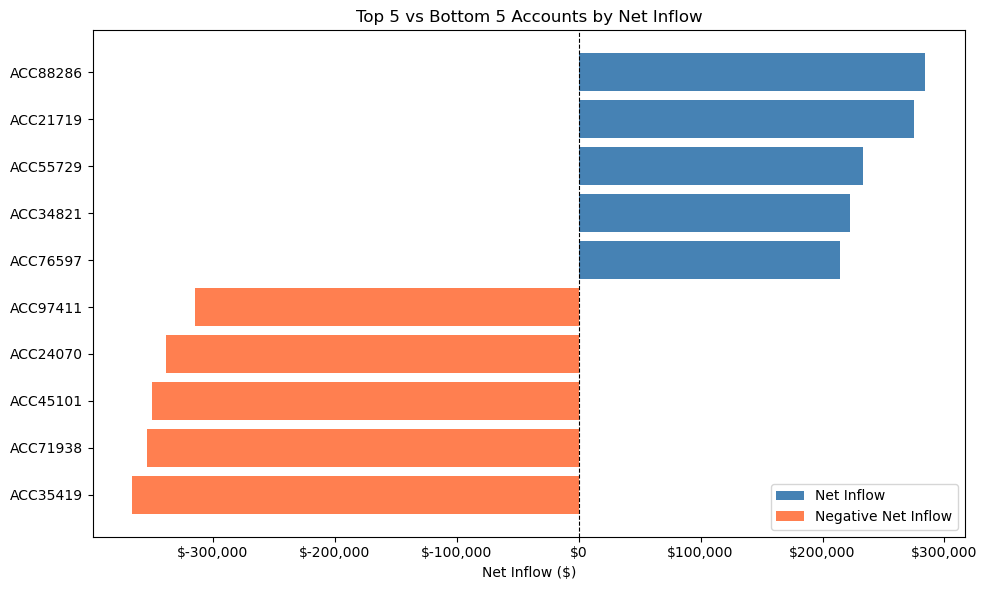

In [127]:
#Identify top and bottom performing accounts based on net inflow
combined = pd.concat([t5, b5]).sort_values('Net Inflow')

colors = ['coral' if i < 0 else 'steelblue' for i in combined['Net Inflow']]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(combined['AccountID'], combined['Net Inflow'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Net Inflow ($)')
ax.set_title('Top 5 vs Bottom 5 Accounts by Net Inflow')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Net Inflow'),
                   Patch(facecolor='coral', label='Negative Net Inflow')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [151]:
summary_df['Activity Levels'].value_counts()# number of customers in each segement

Activity Levels
Low       71
Medium    68
High      45
Name: count, dtype: int64

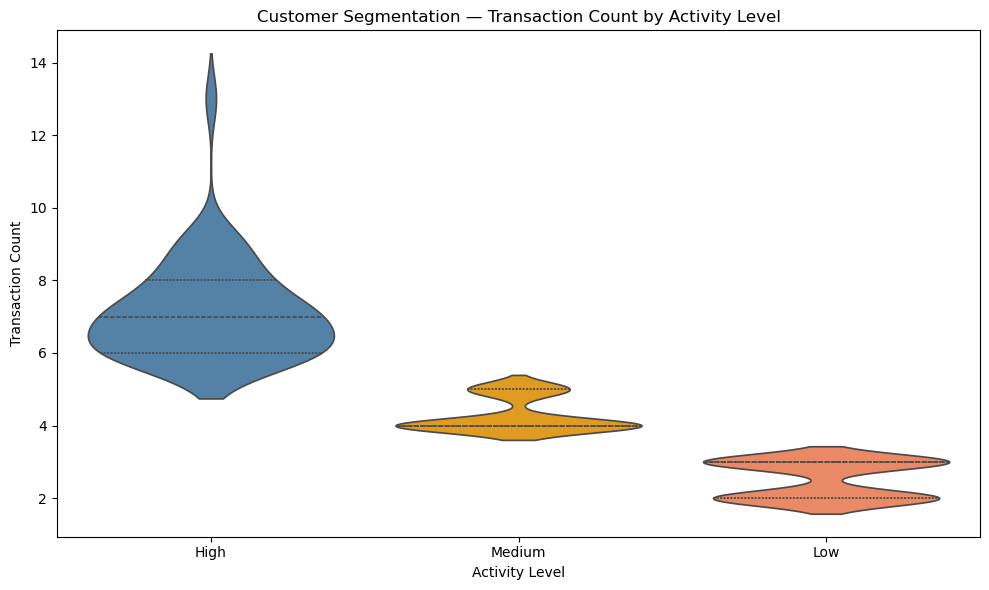

In [153]:
# Activity Levels of Customers 

palette = {
    'High'   : 'coral',
    'Medium' : 'orange',
    'Low'    : 'steelblue'
} # defining a color palette for the segments to be clear distinguishable from each other 

palette = {
    'High'  : 'steelblue',
    'Medium': 'orange',
    'Low'   : 'coral'
}

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=summary_df,
    x='Activity Levels',
    y='Transaction Count',
    hue='Activity Levels',
    palette=palette,
    inner='quartile'
)
plt.title('Customer Segmentation — Transaction Count by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()

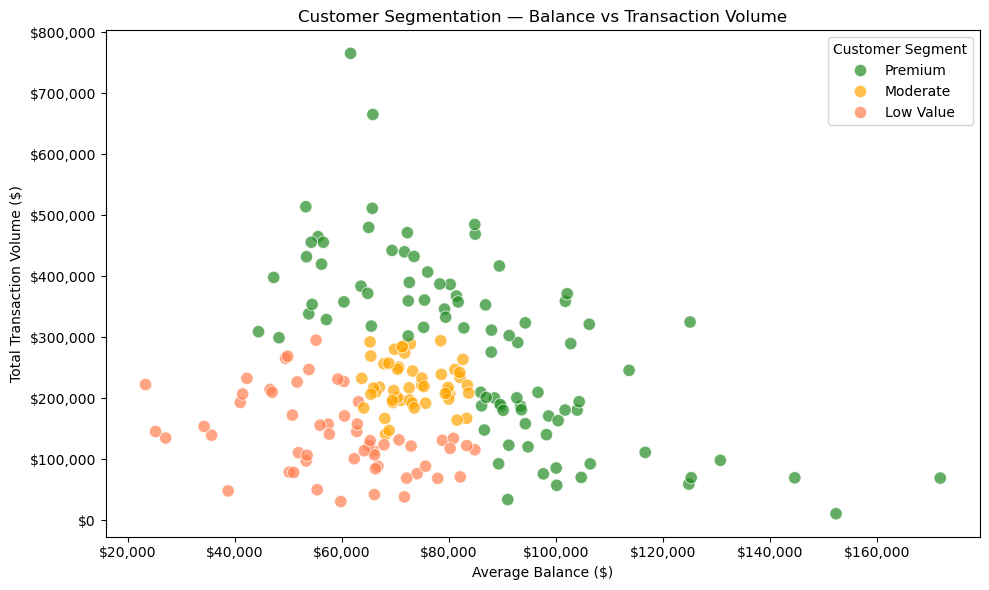

In [168]:
# Segment customers by average balance and transaction volume. 
palette = {
    'Premium'  : 'forestgreen',
    'Moderate' : 'orange',
    'Low Value': 'coral'
}

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=Cus_segment_df,
    x='Average Balance',
    y='Total Transaction Volume',
    hue='Customer Segment',
    hue_order=['Premium','Moderate','Low Value'],
    palette=palette,
    alpha=0.7,
    s=80
)
ax = plt.gca()
plt.title('Customer Segmentation — Balance vs Transaction Volume')
ax.set_xlabel('Average Balance ($)')
ax.set_ylabel('Total Transaction Volume ($)')
plt.legend(title='Customer Segment')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

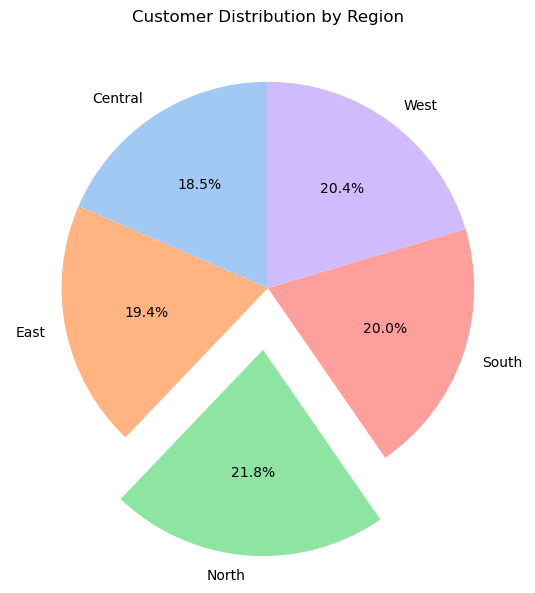

In [157]:
# Demographic Data : Region wise Customer Distribution 
reg_cust_dis = df.groupby('Region')['CustomerID'].count().reset_index()
reg_cust_dis.index = reg_cust_dis.index.astype(str)
plt.figure(figsize=(6, 6))

plt.pie(
    reg_cust_dis['CustomerID'],
    labels=reg_cust_dis['Region'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
    explode = [0,0,0.3,0,0]
)
plt.title('Customer Distribution by Region')
plt.tight_layout()
plt.show()

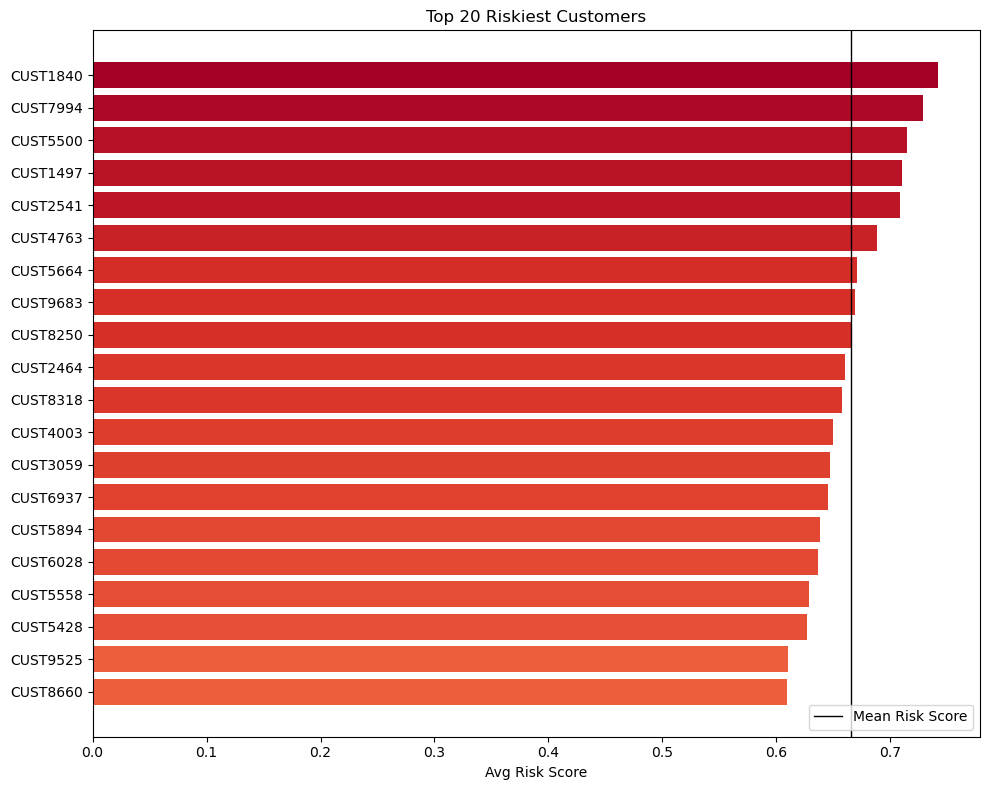

In [159]:
#Risk Score Bar Chart
cus_risk = df.groupby('CustomerID')['RiskScore'].mean()
cus_risk_df = cus_risk.reset_index()
cus_risk_df.columns = ['CustomerID', 'Avg Risk Score']
cus_risk_df = cus_risk_df.sort_values('Avg Risk Score', ascending=False).head(20)

plt.figure(figsize=(10, 8))

bars = plt.barh(
    cus_risk_df['CustomerID'],
    cus_risk_df['Avg Risk Score'],
    color=plt.cm.RdYlGn_r(cus_risk_df['Avg Risk Score'] / cus_risk_df['Avg Risk Score'].max())#Gradient to hightlight whch customer riskiest
)

plt.axvline(cus_risk_df['Avg Risk Score'].mean(), color='black', linewidth=1, linestyle='-', label='Mean Risk Score')
plt.xlabel('Avg Risk Score')
plt.title('Top 20 Riskiest Customers')
plt.legend(loc = 'lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

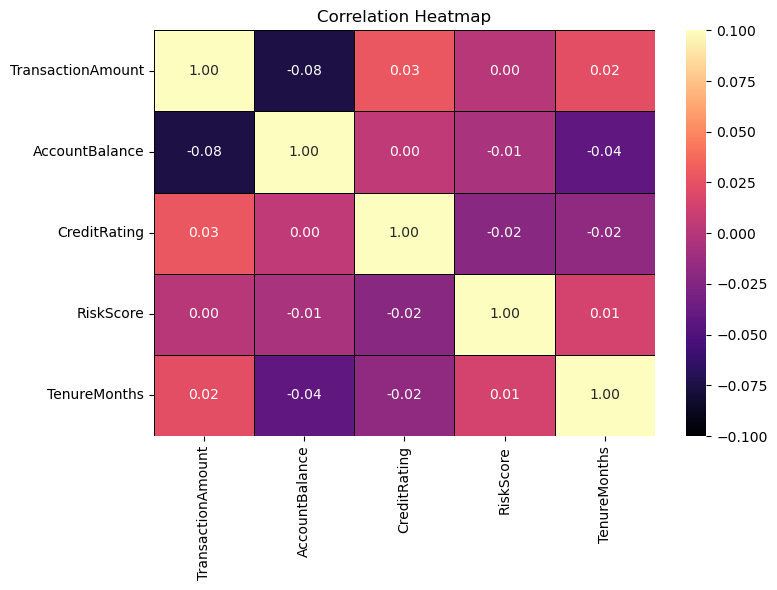

In [174]:
#Heatmap of Financial Categorical columns
corr = df[['TransactionAmount','AccountBalance', 'CreditRating', 'RiskScore','TenureMonths']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='magma',
    vmin=-0.1, vmax=0.1,
    linewidths=0.5,
    linecolor='black'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Task 6**: 
#####  Hypothesis Testing 

In [176]:
# 6.1
# Test whether high-volume transaction accounts have statistically higher average 
# balances than low-volume accounts. 

tran_amt_mean=df.groupby('AccountID')['TransactionAmount'].mean() #mean of each account
df_tran_amt_std=df.groupby('AccountID')['TransactionAmount'].std() # standard 
df_Acc_Balance_mean=df.groupby('AccountID')['AccountBalance'].mean()
df_stats=pd.DataFrame({'Mean of TransactionAmount':tran_amt_mean,'Count of TransactionAmount':txn_count,
                       'Std dev of TransactionAmount':df_tran_amt_std,'AcctBalance Mean':df_Acc_Balance_mean}).reset_index()
df_high_vol= df_stats.loc[(df_stats['Count of TransactionAmount']> 5)][['AcctBalance Mean']].reset_index(drop=True)# 5 is 75%ile of trnasaction count as calculated in task 3.1
df_low_vol = df_stats.loc[(df_stats['Count of TransactionAmount'] < 3)][['AcctBalance Mean']].reset_index(drop=True)# 3 is the 25%ile of transaction count as calculated in task 3.1

from scipy import stats

t_stat,p_value = stats.ttest_ind(df_high_vol,df_low_vol, equal_var=False)# conducting t test
print(f"T-Statistic : {t_stat}")
print(f"p_value : {p_value}")

T-Statistic : [-3.14838821]
p_value : [0.00264561]


In [178]:
#Interpretation
alpha = 0.05 
if p_value < alpha:
    print("Reject null hypothesis: High-volume accounts have significantly different average balances.")
else:
    print("Fail to reject null hypothesis: No significant difference in average balances.")

Reject null hypothesis: High-volume accounts have significantly different average balances.


In [180]:
# 6.2 Conduct hypothesis testing based on segmentation.
# For this we use Anova and Segmentations made in task 3.1
df_high_vol2= df_stats.loc[(df_stats['Count of TransactionAmount']> 5)][['AcctBalance Mean']].reset_index(drop=True)# 5 is 75%ile of trnasaction count as calculated in task 3.1
df_medium_vol = df_stats.loc[(df_stats['Count of TransactionAmount'].isin([4,5]))][['AcctBalance Mean']].reset_index(drop=True)
df_low_vol2 = df_stats.loc[(df_stats['Count of TransactionAmount']>= 3)][['AcctBalance Mean']].reset_index(drop=True)# 3 is the 25%ile of transaction count as calculated in task 3.1

f_stat,p_val=stats.f_oneway(df_high_vol2,df_medium_vol,df_low_vol2)
print(f"F-statistic: {f_stat}, p-value: {p_val}")

F-statistic: [0.39155089], p-value: [0.67640558]


In [182]:
#Interpretation
alpha = 0.05 
if p_val < alpha:
    print("Reject null hypothesis: Segmented Groups have significantly different average balances")
else:
    print("Fail to reject null hypothesis: No significant difference in average balances between segmented groups")

Fail to reject null hypothesis: No significant difference in average balances between segmented groups
